# Rossmann Forecasting — Prophet

**Context.** Rossmann operates 1,115 drugstores across Germany. Planners need a sales outlook several weeks ahead to size inventory and staffing.

**Question.** Can Prophet forecast total daily sales six weeks ahead, and does it match the sklearn result with far less feature work?

**Approach.** Prophet (by Meta) is a purpose-built forecasting library. Instead of hand-crafting lag features, it **decomposes** the series into trend + weekly seasonality + yearly seasonality and fits them together. It takes the raw `(ds, y)` series plus optional regressors.

This is the follow-up to `03_forecasting_sklearn`, which is the lead notebook and explains the problem, the baseline, and the metric choice in full. Here I keep those explanations short and use Prophet as a cross-check: same data, same split, same baseline, almost no feature engineering.

## 1. Load and build the daily series

We start from the clean table produced by `01_etl_pipeline`, keep only **open** days (closed days are zero by definition), and aggregate to one row per day: total sales plus the share of stores promoting. The `ds`/`y` naming is what Prophet expects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_parquet("data/rossmann_clean.parquet")
df["Date"] = pd.to_datetime(df["Date"])
open_df = df[df["Open"] == 1].copy()

daily = (open_df.groupby("Date")
         .agg(y=("Sales", "sum"), PromoShare=("Promo", "mean"))
         .reset_index().rename(columns={"Date": "ds"}))

print("Days:", len(daily), "|", daily["ds"].min().date(), "->", daily["ds"].max().date())
daily.head()


Days: 942 | 2013-01-01 -> 2015-07-31


,ds,y,PromoShare
0,2013-01-01,97235,0.0
1,2013-01-02,6949829,0.0
2,2013-01-03,6347820,0.0
3,2013-01-04,6638954,0.0
4,2013-01-05,5951593,0.0


One row per day: `ds` (date), `y` (total sales — the target), `PromoShare` (fraction of stores promoting, 0–1).

Note that unlike the sklearn approach, **no lag features are needed** — Prophet builds its own internal representation of time from the dates themselves.


## 2. Chronological split

The test set is the **last 42 days (6 weeks)**, the same split as the sklearn notebook, where the choice of horizon is explained. It's by position in time, never random: the model must not see any test-period day during training.

In [2]:
horizon = 42
train = daily.iloc[:-horizon][["ds", "y", "PromoShare"]]
test = daily.iloc[-horizon:][["ds", "PromoShare"]]
actual = daily.iloc[-horizon:]["y"].values

print("Train:", train["ds"].min().date(), "->", train["ds"].max().date())
print("Test :", test["ds"].min().date(), "->", test["ds"].max().date())


Train: 2013-01-01 -> 2015-06-19
Test : 2015-06-20 -> 2015-07-31


## 3. Metrics and baseline

Same three metrics as the sklearn notebook: **MAE** (average miss in sales units), **RMSE** (punishes large misses harder), and **WAPE** (total error ÷ total actual sales). I use WAPE instead of MAPE because the series has public-holiday days where sales fall near ~100,000, which makes MAPE explode; the sklearn notebook explains this in full.

The **baseline** is the same too: predict "same weekday last week" (`shift(7)`). Establishing it before modelling is what makes the model's error meaningful.

In [3]:
def mae(a, f):  return np.mean(np.abs(a - f))
def rmse(a, f): return np.sqrt(np.mean((a - f) ** 2))
# WAPE (weighted absolute percentage error) instead of MAPE — see note above.
def wape(a, f): return np.sum(np.abs(a - f)) / np.sum(np.abs(a)) * 100

snaive_pred = daily["y"].shift(7).iloc[-horizon:].values
print(f"Seasonal-naive  MAE {mae(actual, snaive_pred):,.0f}  RMSE {rmse(actual, snaive_pred):,.0f}  WAPE {wape(actual, snaive_pred):.2f}%")


Seasonal-naive  MAE 2,019,637  RMSE 2,560,492  WAPE 30.17%


The baseline is off by about **30% of total sales** (WAPE), averaging ~2.0M per day. That's the bar to beat.

## 4. Fit Prophet

Configuration follows directly from the EDA:

- **weekly seasonality on** — the day-of-week effect is the dominant pattern.
- **yearly seasonality on** — there's a clear December peak.
- **daily seasonality off** — we have one point per day, so there is no within-day pattern to learn.
- **`PromoShare` as a regressor** — promotions drive a large lift; without this Prophet would treat promo days as unexplained noise.


In [4]:
m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m.add_regressor("PromoShare")
m.fit(train)

forecast = m.predict(test)
prophet_pred = forecast["yhat"].values

results = pd.DataFrame(
    {"Seasonal-naive": [mae(actual, snaive_pred), rmse(actual, snaive_pred), wape(actual, snaive_pred)],
     "Prophet":        [mae(actual, prophet_pred), rmse(actual, prophet_pred), wape(actual, prophet_pred)]},
    index=["MAE", "RMSE", "WAPE"],
).T.round(2)
results


18:22:52 - cmdstanpy - INFO - Chain [1] start processing
18:22:52 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,WAPE
Seasonal-naive,2019637.26,2560492.36,30.17
Prophet,558693.08,778828.51,8.35


**Prophet cuts the baseline's error by about two-thirds** — a decisive improvement, not a marginal one. MAE drops from ~2.0M to ~559k.

Prophet does well here because the series is exactly what it's designed for: strong weekly seasonality, a yearly cycle, a smooth trend, and one external regressor. It handles the strong weekly shape, including the near-total Sunday shutdown, without being told about it — it learns the day-of-week effect directly from the dates.

## 5. Forecast vs actual

The table summarises accuracy; the plot shows *where* the model misses, which the metrics hide.


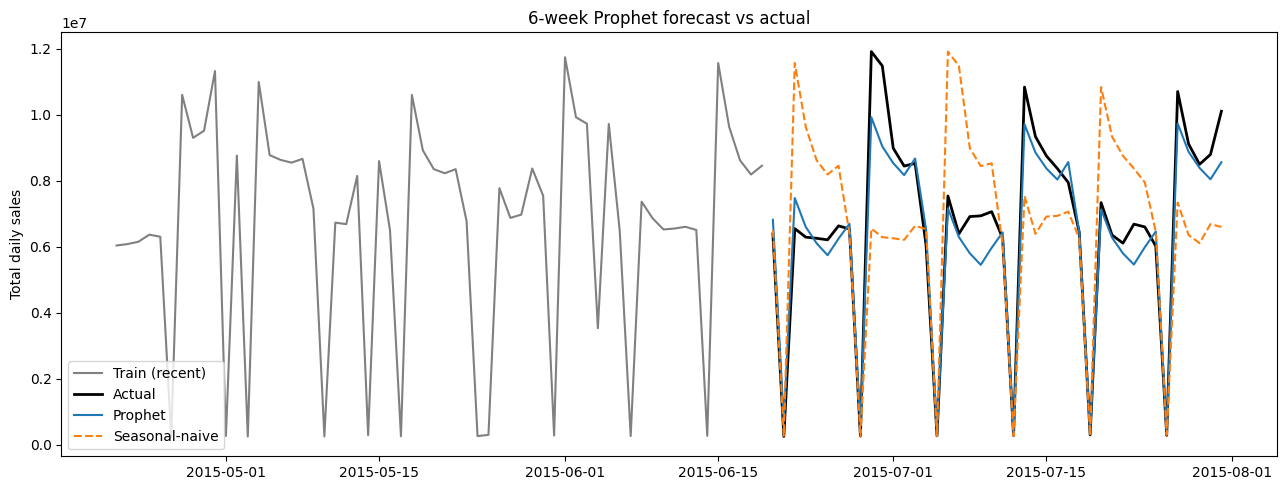

In [5]:
plt.figure(figsize=(13, 5))
ctx = daily.iloc[-(horizon+60):-horizon]
plt.plot(ctx["ds"], ctx["y"], color="gray", label="Train (recent)")
plt.plot(daily.iloc[-horizon:]["ds"], actual, color="black", lw=2, label="Actual")
plt.plot(daily.iloc[-horizon:]["ds"], prophet_pred, color="tab:blue", label="Prophet")
plt.plot(daily.iloc[-horizon:]["ds"], snaive_pred, ls="--", color="tab:orange", label="Seasonal-naive")
plt.title("6-week Prophet forecast vs actual")
plt.ylabel("Total daily sales"); plt.legend(); plt.tight_layout(); plt.show()


Prophet follows the actual line closely, much like Random Forest in the sklearn notebook. It tracks the weekly zig-zag well, and in particular catches the sharp Sunday drop each week. The main misses are a Monday peak (the one just before 7 July), which it under-predicts, and the middle of the week of 8 July, where it runs a little high. Overall the forecast is satisfactory: the seasonal-naive baseline (dashed) swings much further from actual on normal days, while Prophet stays close throughout.

## 6. What Prophet learned

Prophet's main advantage over a black-box regressor is that its components are inspectable. The `plot_components` panels show each piece it estimated and added together to produce the forecast.


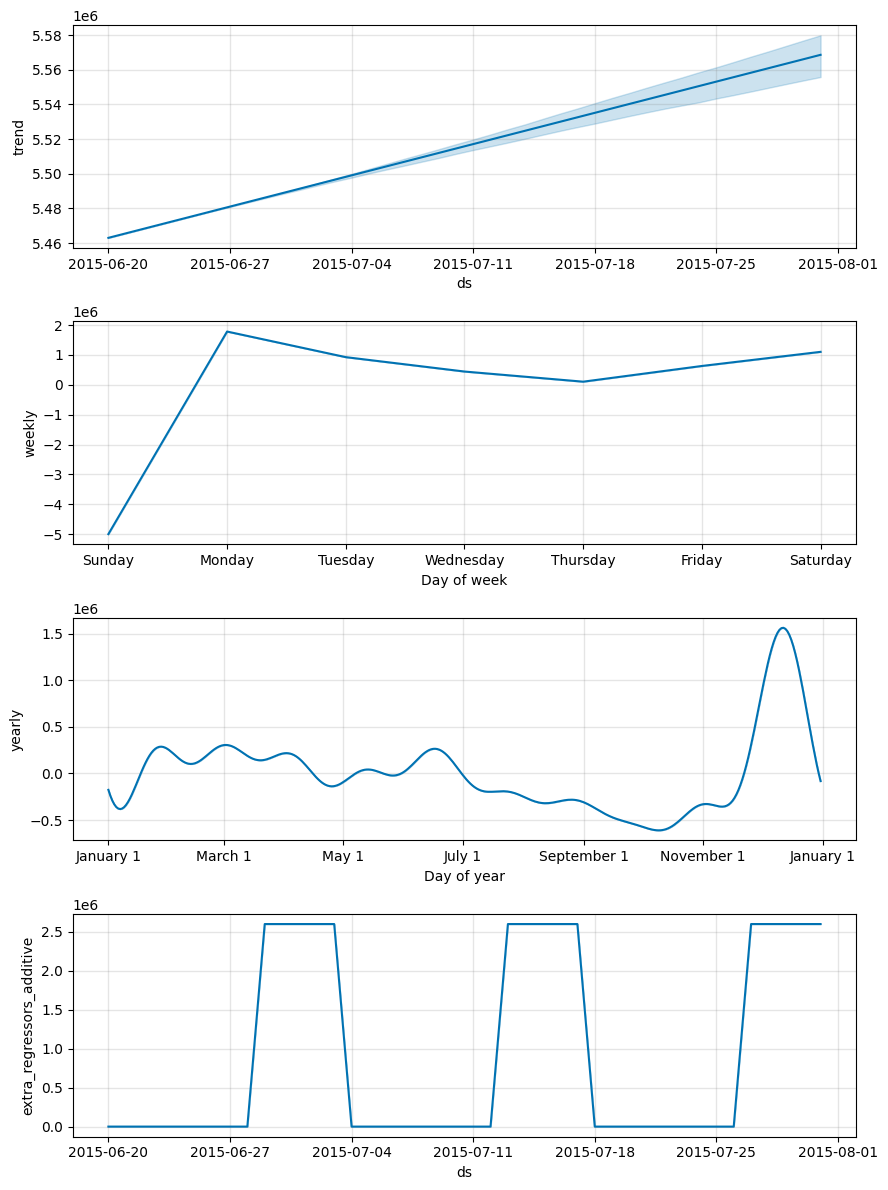

In [6]:
fig = m.plot_components(forecast)
plt.show()


**How to read these panels.** Prophet builds its forecast by *adding* pieces: `trend + weekly + yearly + promo`. So each panel below is a *shift away from the baseline trend*, not a sales figure on its own. This matters for reading the weekly panel (see the note on Sunday).

- **Trend** — a mild rise across the window (~5.46M → ~5.57M), only about +2% over the two-and-a-half years. This matches the EDA: sales grow slightly year to year, but the series is basically flat and stable, not a strong growth trend.
- **Weekly** — the same shape the EDA found: Sunday far below the rest of the week, Monday the high point, the other days in between. This is the dominant pattern.
- **Yearly** — also matches the EDA: fairly flat most of the year with a clear December peak, and a late-summer low.
- **PromoShare** — a clean square wave of about +2.6M, Prophet's estimate of the promo lift. It closely matches the linear model's promo coefficient from the sklearn notebook, two different methods landing on the same number, which is a good sanity check.

> **Why is Sunday "negative"?** The weekly panel dips to about −5M on Sunday, but that isn't negative revenue, which of course can't happen. Each panel is a *shift from the trend*, so −5M means "on a Sunday, subtract about 5M from the ~5.5M trend", which lands near 0.5M, low but positive. Almost all stores close on Sunday, so the total collapses; Prophet represents that as a large negative weekly shift, and the pieces always add back to a positive forecast.

## 7. Recommendation

- **Prophet cuts the seasonal-naive baseline's error by roughly two-thirds** (MAE ~2.0M → ~559k) with very little code, capturing weekly and yearly seasonality plus the promo lift automatically.
- **Its component decomposition makes the seasonal structure easy to communicate.** The `forecast` frame also holds uncertainty columns (`yhat_lower` / `yhat_upper`); I don't plot them here, but they could be used as forecast bands for planning.
- **Prophet lands close to the sklearn Random Forest**, reached by a very different route: almost no feature work versus explicit lag engineering. Its independent promo estimate agrees with the linear model's, which is reassuring.
- **Business use:** because `PromoShare` enters as a regressor, planners can run promo vs. non-promo scenarios on the six-week outlook before committing to a campaign.
- **On metrics:** I use WAPE rather than MAPE, for the reason explained in the sklearn notebook.
- **Limitations:** Prophet is more of a black box than the lag-feature approach, so the sklearn notebook is preferable when the logic must be fully explained. Like the sklearn notebook, this forecasts the company total, not individual stores. And accuracy rests on a single six-week window: testing on just one period can be lucky or unlucky, so a more robust estimate would re-run the forecast from many different cut-off dates and average the error (Prophet's built-in `cross_validation` does exactly this rolling evaluation).

- **Prophet-specific next steps I'd try:** add a holidays table (Prophet has built-in support, and the holiday closures are the biggest source of error here), and run `Prophet.cross_validation` for a rolling-origin estimate instead of relying on one six-week window. Beyond Prophet, the same extensions as the sklearn notebook apply: per-store models and the unused store metadata (`StoreType`, `CompetitionDistance`, holiday flags).